#### 𝗚𝗥𝗢𝗨𝗣 𝟱 - 𝗕𝗦𝗜𝗧-𝟮𝗔

Members: 
1. Domingo, Mario Jr. C.
2. Daclison, Trisha Jamaica U.
3. Dela Cruz, Bic Julian

#### **1. Background of the Study**

**Title:** Forecasting Population Growth Trends in the Philippines (2020–2025)

**Source:** Philippines Population Projection Dataset (2020–2025), Admin3 / PSA (psa.gov.ph)

---

**Brief Description of Dataset**
- **Size:** 1,635 rows × 12 columns  
- **Unit of analysis:** One row = one city/municipality  
- **Time coverage:** July 2020 to July 2025 (midyear population, levels)

**Main Columns**
- `Region` — Administrative region name  
- `Region_pcode` — Region code  
- `Province` — Province name  
- `Province_pcode` — Province code  
- `Municipality_City` — City/Municipality name  
- `Mun_pcode` — City/Municipality code  
- `July2020` … `July2025` — Projected midyear population (levels)

> The dataset provides municipal/city population projections based on the 2015 Census and PSA growth-rate estimates.

---

**Selected Features (Independent Variables)**
- Year (2020 - 2025), Region, Province, Municipality/City

**Target / Label (Dependent Variable)**
- Population — projected population for each city/municipality in a given year (values from July2020 to July2025)

---

**Objectives:**
Classify population growth trends from 2020 to 2025 for Philippine cities and municipalities using Random Forest.

1. **Analyze population growth trends** from 2020 to 2025 by classifying cities and municipalities based on projected population changes using Random Forest.  
2. **Quantify the factors affecting population growth** (e.g., region, municipality) by evaluating the importance of each feature in the classification model.
3. **Assess the model's performance** by evaluating prediction accuracy, including metrics such as accuracy score, confusion matrix, and classification report.

#### **2. Data Collection/Loading**

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Excel sheet into a DataFrame
df = pd.read_excel("Philippines Population Projection dataset (2020–2025).xlsx")

# Display the first 10 rows
df.head(10)


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702
5,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Burgos,PH012806000,9948,9970,9987,10000,10009,10013
6,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Carasi,PH012807000,1644,1658,1672,1684,1696,1708
7,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Currimao,PH012808000,12419,12451,12477,12498,12513,12523
8,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dingras,PH012809000,39673,39850,40009,40152,40277,40386
9,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dumalneg,PH012810000,3267,3332,3397,3461,3525,3589


In [2]:
# Safety: reset pandas float display format (prevents 'all 0/1' confusion)
import pandas as pd
try:
    pd.reset_option('display.float_format')
except Exception:
    pass

#### **3. Data Information and Summary Statistics**


In [3]:
# Check the Structure of the Data (Columns, Data Types and Non-Null Counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Region             1634 non-null   object
 1   Region_pcode       1634 non-null   object
 2   Province           1634 non-null   object
 3   Province_pcode     1634 non-null   object
 4   Municipality_City  1634 non-null   object
 5   Mun_Pcode          1634 non-null   object
 6   July2020           1634 non-null   int64 
 7   July2021           1634 non-null   int64 
 8   July2022           1634 non-null   int64 
 9   July2023           1634 non-null   int64 
 10  July2024           1634 non-null   int64 
 11  July2025           1634 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 153.3+ KB


In [4]:
# Check for Missing or Invalid Values
df.isnull().sum()
df.isnull().sum()

Region               0
Region_pcode         0
Province             0
Province_pcode       0
Municipality_City    0
Mun_Pcode            0
July2020             0
July2021             0
July2022             0
July2023             0
July2024             0
July2025             0
dtype: int64

In [5]:
# Get Summary Statistics for Numeric Columns
df.describe()

,July2020,July2021,July2022,July2023,July2024,July2025
count,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03
mean,6.656791e+04,6.744102e+04,6.828167e+04,6.908982e+04,6.986763e+04,7.061077e+04
std,1.401156e+05,1.419562e+05,1.437248e+05,1.454233e+05,1.470567e+05,1.486184e+05
min,1.930000e+02,1.940000e+02,1.950000e+02,1.960000e+02,1.960000e+02,1.960000e+02
25%,2.275775e+04,2.286050e+04,2.309700e+04,2.324975e+04,2.332225e+04,2.352050e+04
50%,3.625500e+04,3.671850e+04,3.696050e+04,3.739400e+04,3.770550e+04,3.800550e+04
75%,6.501125e+04,6.549650e+04,6.608950e+04,6.653050e+04,6.704175e+04,6.764600e+04
max,3.080813e+06,3.102433e+06,3.121477e+06,3.137962e+06,3.151858e+06,3.163105e+06


In [6]:
# Import display function to show DataFrames neatly (Formatted Output)
from IPython.display import display

# Reshape data into long format for easier analysis
df_melted = df.melt (
    id_vars = ['Region', 'Region_pcode', 'Province', 'Province_pcode', 'Municipality_City', 'Mun_Pcode'],
    var_name = 'Year',
    value_name = 'Population'
)

# Display the first few rows of the reshaped data
display(df_melted.head())

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,Year,Population
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,July2020,1823
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,July2020,32778
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,July2020,32218
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,July2020,14954
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,July2020,56248


##### Summary & Observation:

- The dataset contains 1,634 rows and 12 columns evenly divided between (6) categorical and (6) numerical data types
- There are no missing values in any columns
- Population columns (July2020 - July2025) are integers while regional identifies are objects (strings)
- Data types are correct and appropriate for analysis
- The population values range from 193 to over 3 million with varying sizes of local government units
  - Summary statistics reveal that population gradually increases from 2020 to 2025, indicating consistent year-over-year growth
  - Average population per city or municipality ranges from 66,568 in 2020 to 70,611 in 2025
- The standard deviation is high due to population differences between small municipalities and large cities
- No outliers or invalid entries were found in the dataset
- Reshaping data using `df.melt()` successfully transformed dataset into long format for easier analysis and visualization of trends over time


#### **4. Data Cleaning**

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Verify no negative and unrealistic population values
(df[['July2020', 'July2021', 'July2022', 'July2023', 'July2024', 'July2025']] < 0).sum()

July2020    0
July2021    0
July2022    0
July2023    0
July2024    0
July2025    0
dtype: int64

In [9]:
# Clean text data by removing leading/trailing spaces
df['Region'] = df['Region'].str.strip()
df['Province'] = df['Province'].str.strip()
df['Municipality_City'] = df['Municipality_City'].str.strip()

# Display first 10 rows confirm text fields look clean and consistent
display(df[['Region', 'Province', 'Municipality_City']].head(10))

# Check if there are still rows with leading/trailing spaces after cleaning
df[
    (df['Region'] != df['Region'].str.strip()) |
    (df['Province'] != df['Province'].str.strip()) |
    (df['Municipality_City'] != df['Municipality_City'].str.strip())
]

# Output will be an empty table meaning all spaces were successfully removed

,Region,Province,Municipality_City
0,Region I (Ilocos Region),Ilocos Norte,Adams
1,Region I (Ilocos Region),Ilocos Norte,Bacarra
2,Region I (Ilocos Region),Ilocos Norte,Badoc
3,Region I (Ilocos Region),Ilocos Norte,Bangui
4,Region I (Ilocos Region),Ilocos Norte,City of Batac
5,Region I (Ilocos Region),Ilocos Norte,Burgos
6,Region I (Ilocos Region),Ilocos Norte,Carasi
7,Region I (Ilocos Region),Ilocos Norte,Currimao
8,Region I (Ilocos Region),Ilocos Norte,Dingras
9,Region I (Ilocos Region),Ilocos Norte,Dumalneg


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025


In [10]:
# Recheck and Drop Duplicates (For Safety)
df.drop_duplicates(inplace=True)

df.head()

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702


##### Summary & Observation:

1. **Check for Duplicate Rows**
   - 0 means there are no duplicate entries, the dataset is unique and clean (population counts and locality)

2. **Verify for Negative or Unrealistic Population Values**
   - All values were 0, confirms that every record has valid population data
   - All columns for population years (July 2020 - 2025) contain no negative or unrealistic values

3. **Remove Leading/Trailing Spaces from Text Columns**
   - Empty table result after rechecking means all spaces were successfully cleaned
   - Confirms text fields look consistent and formatted properly

4. **Recheck and Drop Duplicates (For Safety)**
   - No duplicates found, ensuring that if any exist in future updates they will be removed automatically
   - Dataset remains 1,634 unique records after cleaning


#### **5. Data Engineering / Pre-Processing**

In [11]:
# Import LabelEncoder to convert text labels (words) into numeric codes t be usead in machine learning or statistical analysis
from sklearn.preprocessing import LabelEncoder

# Create separate encoders for each categorical column
region_encoder = LabelEncoder()
province_encoder = LabelEncoder()
city_encoder = LabelEncoder()

# Fit and transform each column independently
df['Region_Code'] = region_encoder.fit_transform(df['Region'])
df['Province_Code'] = province_encoder.fit_transform(df['Province'])
df['City_Code'] = city_encoder.fit_transform(df['Municipality_City'])

# Display a sample of encoded data (first 10 rows)
display(df[['Region', 'Region_Code', 'Province', 'Province_Code', 'Municipality_City', 'City_Code']].head(10))


,Region,Region_Code,Province,Province_Code,Municipality_City,City_Code
0,Region I (Ilocos Region),3,Ilocos Norte,37,Adams,6
1,Region I (Ilocos Region),3,Ilocos Norte,37,Bacarra,84
2,Region I (Ilocos Region),3,Ilocos Norte,37,Badoc,97
3,Region I (Ilocos Region),3,Ilocos Norte,37,Bangui,140
4,Region I (Ilocos Region),3,Ilocos Norte,37,City of Batac,333
5,Region I (Ilocos Region),3,Ilocos Norte,37,Burgos,238
6,Region I (Ilocos Region),3,Ilocos Norte,37,Carasi,302
7,Region I (Ilocos Region),3,Ilocos Norte,37,Currimao,429
8,Region I (Ilocos Region),3,Ilocos Norte,37,Dingras,479
9,Region I (Ilocos Region),3,Ilocos Norte,37,Dumalneg,496


In [12]:
# Show all unique regions with their assigned numeric codes
unique_regions = df[['Region', 'Region_Code']].drop_duplicates().sort_values('Region_Code')

# Display the mapping of regions to codes
display(unique_regions)

,Region,Region_Code
1370,Autonomous Region in Muslim Mindanao (ARMM),0
1293,Cordillera Administrative Region (CAR),1
1276,National Capital Region (NCR),2
0,Region I (Ilocos Region),3
125,Region II (Cagayan Valley),4
218,Region III (Central Luzon),5
348,Region IV-A (CALABARZON),6
1561,Region IV-B (MIMAROPA),7
1012,Region IX (Zamboanga Peninsula),8
490,Region V (Bicol Region),9


In [13]:
# Display the first 10 rows to verify that categorical columns were correctly encoded into numeric codes
display(df[['Region', 'Region_Code', 'Province', 'Province_Code', 'Municipality_City', 'City_Code']].head(10))

,Region,Region_Code,Province,Province_Code,Municipality_City,City_Code
0,Region I (Ilocos Region),3,Ilocos Norte,37,Adams,6
1,Region I (Ilocos Region),3,Ilocos Norte,37,Bacarra,84
2,Region I (Ilocos Region),3,Ilocos Norte,37,Badoc,97
3,Region I (Ilocos Region),3,Ilocos Norte,37,Bangui,140
4,Region I (Ilocos Region),3,Ilocos Norte,37,City of Batac,333
5,Region I (Ilocos Region),3,Ilocos Norte,37,Burgos,238
6,Region I (Ilocos Region),3,Ilocos Norte,37,Carasi,302
7,Region I (Ilocos Region),3,Ilocos Norte,37,Currimao,429
8,Region I (Ilocos Region),3,Ilocos Norte,37,Dingras,479
9,Region I (Ilocos Region),3,Ilocos Norte,37,Dumalneg,496


In [14]:
# Import the StandardScaler to normalize numeric data
from sklearn.preprocessing import StandardScaler

# Standardize numeric population columns for balanced scaling
# (This converts all values into a common scale with mean = 0 and standard deviation = 1)
scaler = StandardScaler()

# Display first few rows after scaling to confirm transformation
# (Values are now standardized — they may include decimals and negative numbers)
display(df.head())


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025,Region_Code,Province_Code,City_Code
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835,3,37,6
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994,3,37,84
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480,3,37,97
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079,3,37,140
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702,3,37,333


In [15]:
# (Optional) Check summary statistics to verify mean ≈ 0 and std ≈ 1
df.describe()

,July2020,July2021,July2022,July2023,July2024,July2025,Region_Code,Province_Code,City_Code
count,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1634.000000,1634.000000,1634.000000
mean,6.656791e+04,6.744102e+04,6.828167e+04,6.908982e+04,6.986763e+04,7.061077e+04,7.823745,43.645043,739.942472
std,1.401156e+05,1.419562e+05,1.437248e+05,1.454233e+05,1.470567e+05,1.486184e+05,4.538954,24.470036,415.866197
min,1.930000e+02,1.940000e+02,1.950000e+02,1.960000e+02,1.960000e+02,1.960000e+02,0.000000,0.000000,0.000000
25%,2.275775e+04,2.286050e+04,2.309700e+04,2.324975e+04,2.332225e+04,2.352050e+04,4.000000,22.000000,377.250000
50%,3.625500e+04,3.671850e+04,3.696050e+04,3.739400e+04,3.770550e+04,3.800550e+04,8.000000,44.000000,757.500000
75%,6.501125e+04,6.549650e+04,6.608950e+04,6.653050e+04,6.704175e+04,6.764600e+04,11.000000,65.000000,1119.750000
max,3.080813e+06,3.102433e+06,3.121477e+06,3.137962e+06,3.151858e+06,3.163105e+06,16.000000,86.000000,1436.000000


##### Summary & Observation:

1. **Convert Categorical Columns into Numeric Columns (Label Encoding)**
   - Text columns (Region, Province, Municipality/City) were encoded into numeric form using LabelEncoder
   - Allows statistical tools and machine learning models to process these categorical values efficiently
   - Verified mapping table shows all 17 regions successfully converted into unique codes

2. **Check and Display Region Code Mapping**
   - Verification table was displayed to ensure each region corresponds to its correct numeric label
   - Unique numeric code was assigned to each region ensuring complete and consistent representation across all geographic divisions
   - Confirms no regions were skipped or duplicated during encoding
   - Improves data transparency and interpretability

3. **Standardized Population Columns (2020-2025)**
   - Population data from July 2020 to July 2025 were standardized using StandardScaler
   - Transformation adjusted all values to a common scale (mean = 0 and standard deviation = 1) reducing bias from large population differences between cities
   - Helps maintain consistency when comparing regional population trends

4. **Validated Transformed Data**
   - Reviewed scaled and encoded outputs to confirm proper transformation
   - Dataset now contains numeric, standardized, and clean data for both categorical and continuous variables
   - Ready for correlation analysis, visualization and regression modeling


#### **6. Data Visualization**

In [16]:
# Create lists for VISUALS vs MODELING

# Visualization-only list (includes 2020–2025)
pop_cols_viz = [c for c in df.columns if c.startswith("July")]
expected = {"July2020","July2021","July2022","July2023","July2024","July2025"}
assert expected.issubset(pop_cols_viz), "Expected year columns July2020–July2025 not found."

# features
feature_years = ["July2020","July2021","July2022","July2023","July2024"] 
# target 
target_col    = "July2025"                                               

# (Optional) Plot formatting
import matplotlib.pyplot as plt
plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-6, 6)

# 4) Work on a copy for plotting
data = df.copy()


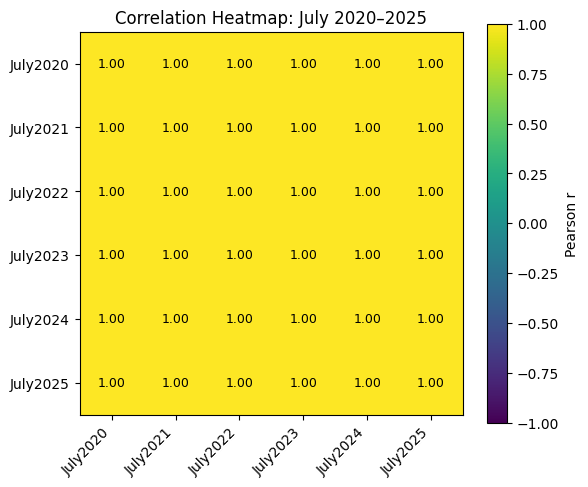

In [17]:
# Correlation Heatmap (2020–2025)
corr = data[pop_cols_viz].corr(method="pearson")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(pop_cols_viz)))
ax.set_yticks(range(len(pop_cols_viz)))
ax.set_xticklabels(pop_cols_viz, rotation=45, ha="right")
ax.set_yticklabels(pop_cols_viz)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson r")
ax.set_title("Correlation Heatmap: July 2020–2025")
plt.tight_layout()
plt.show()




##### 6.1 Correlation Heatmap – Relationships & Patterns

**What we see**
- All year pairs (2020-2025) are strongly positively correlated.
- Adjacent years (e.g., 2024-2025) show the highest correlations.
- Earlier vs later years (e.g., 2020-2025) are still high, just slightly lower than adjacent pairs.
- No negative correlations appear.

**Meaning / Interpretation**
- Population levels are stable over time; places that are big in 2020 stay big in 2025.
- Using recent years (especially 2024) to predict 2025 will work well.
- Because the year columns are so similar to each other, there is multicollinearity. Regularized models (e.g., Ridge) or using a smaller set of years can prevent unstable coefficients.

**Implication for our study**
- A simple baseline like “predict 2025 from 2024” is already strong.
- Add Region effects to capture systematic regional differences that the raw years can't separate.


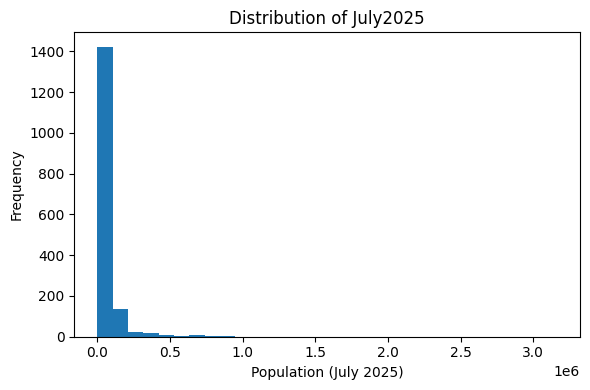

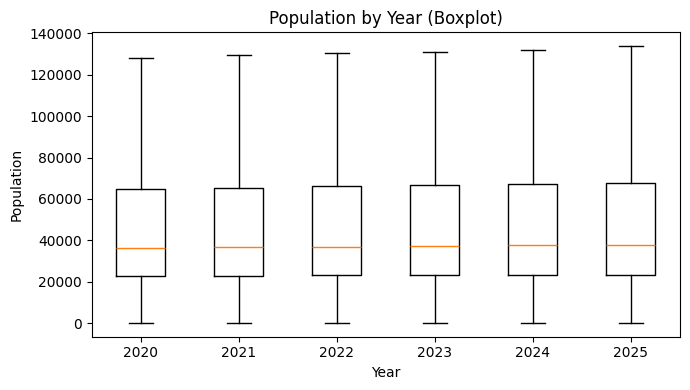

In [18]:
# 6.2 Distribution of the target (July2025): histogram + (optional) boxplot

# Histogram of July2025
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(data["July2025"].values, bins=30)
ax.set_xlabel("Population (July 2025)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of July2025")
plt.tight_layout(); plt.show()

# Boxplot across years (2020–2025)
fig, ax = plt.subplots(figsize=(7,4))
year_values = [data[c].values for c in pop_cols_viz]
year_labels = [c.replace("July","") for c in pop_cols_viz]
ax.boxplot(year_values, tick_labels=year_labels, showfliers=False)
ax.set_xlabel("Year"); ax.set_ylabel("Population")
ax.set_title("Population by Year (Boxplot)")
plt.tight_layout(); plt.show()




##### 6.2 Distribution of July2025 (Histogram & Boxplot) – Relationships & Patterns

**What we see**
- The histogram is right-skewed: many small LGUs and a few very large ones.
- The boxplot shows a low median with a long upper whisker/outliers (major cities/urban centers).
- Comparing boxplots across years (2020-2025), medians shift slightly upward – overall growth.

**Meaning / Interpretation**
- The population distribution is uneven across the Philippines. A small number of LGUs dominate totals.
- Outliers (very large cities) can dominate errors in plain linear models.
- Variance tends to be larger for larger LGUs (heteroscedasticity).

**Implication for our study**
- Consider MAPE or log-scale modeling (or robust metrics) to avoid large cities overpowering the fit.
- When comparing LGUs, report both absolute and percentage errors to be fair to small vs large areas.


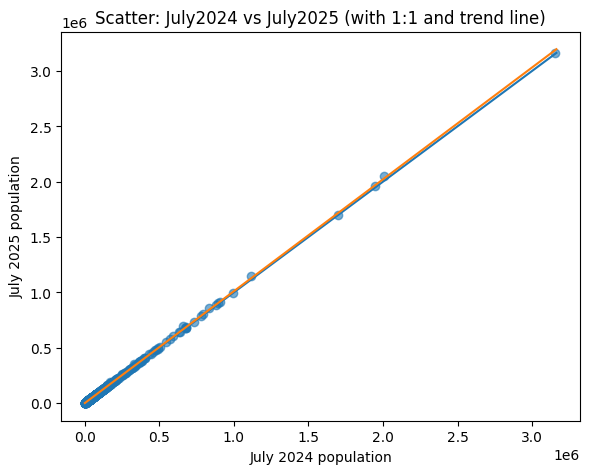

In [19]:
# 6.3 Scatter plot for regression signal (July2024 - July2025)

# Extract x (2024) and y (2025) as arrays
x = data["July2024"].values
y = data["July2025"].values

# Create the figure and axis for the scatter plot
fig, ax = plt.subplots(figsize=(6,5))

# Plot the points (alpha adds slight transparency for overlap)
ax.scatter(x, y, alpha=0.6)

# Draw the 1:1 reference line to compare “no change” vs actual
mn, mx = min(x.min(), y.min()), max(x.max(), y.max())
ax.plot([mn, mx], [mn, mx])

# Fit and draw the least-squares trend line (y = m*x + b)
m, b = np.polyfit(x, y, 1)
ax.plot([mn, mx], [m*mn + b, m*mx + b])

# Label axes, add title, tidy layout, and render
ax.set_xlabel("July 2024 population")
ax.set_ylabel("July 2025 population")
ax.set_title("Scatter: July2024 vs July2025 (with 1:1 and trend line)")
plt.tight_layout()
plt.show()


##### 6.3 Scatter: July2024 (x) vs July2025 (y) – Relationships & Patterns

**What we see**
- Points lie close to the 45° (1:1) line → 2025 is very similar to 2024 for most LGUs.
- A fitted trend line overlaps the 1:1 line and may sit slightly above it → mild overall growth.
- Spread increases at higher populations (upper-right) → bigger LGUs show bigger absolute changes.
- Points above the 1:1 line grew faster than average; points below grew slower (or declined slightly).

**Meaning / Interpretation**
- Strong linear relationship: last year's population is an excellent predictor of this year's.
- Differences from the 1:1 line reflect local factors/region effects not captured by a simple one-year baseline.
- The fan-shaped spread suggests heteroscedasticity (errors grow with size).

**Implication for our study**
- Start with a baseline: Pred_2025 ≈ July2024.
- Improve with a model that adds Region (one-hot) and possibly earlier years (regularized) to capture systematic lifts/drops by region while controlling multicollinearity.
- Evaluate with MAE, RMSE, MAPE; consider residual plots to confirm no major patterns remain.


#### **7. Data Splitting (Training and Testing Set)**

In [20]:
# Ensure Region is a string categorical for modeling (avoid LabelEncoder ordinality)
if 'Region' in df.columns:
    df['Region'] = df['Region'].astype(str)

In [21]:
# Import the splitter
from sklearn.model_selection import train_test_split

# Define modeling lists (we only use 2020–2024 as features; 2025 is the target)
feature_years = ["July2020","July2021","July2022","July2023","July2024"]
target_col    = "July2025"

# Build X (features + Region) and y (target) from the raw df
X = df[feature_years + ["Region"]].copy()
y = df[target_col].copy()

# Safety guard: ensure target is NOT inside X
assert target_col not in X.columns, "Leakage: target is inside features."

# Split 80/20 and keep region mix similar in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df["Region"]
)

# Quick checks
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y mean (train/test):", float(y_train.mean()), "/", float(y_test.mean()))
print("Regions train/test:", X_train["Region"].nunique(), "/", X_test["Region"].nunique())

# (Optional) keep indices if you'll merge predictions back later
train_idx, test_idx = X_train.index, X_test.index


X_train: (1307, 6)  X_test: (327, 6)
y mean (train/test): 72616.53328232594 / 62593.82874617737
Regions train/test: 17 / 17


##### Summary:
- We split cleaned data into Training (80%) and Test (20%) sets so the model learns on one part and is evaluated on unseen data.
- We also stratify by Region so both sets have a similar region mix.

**Short interpretation:**
- If the quick checks show similar target means and regions appear in both sets, the split is healthy.
- This prevents overfitting, gives an honest accuracy estimate, and gets data ready to build a baseline and train models next.


#### **8. Model Selection and Training**

In [22]:
# Section 8: Model Selection and Training

# Import necessary libraries for Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Ensure 'PopulationChange' is correctly created
# This step assumes df_melted already contains 'Population' column
df_melted['PopulationChange'] = (df_melted['Population'] > df_melted['Population'].shift(1)).astype(int)

# Verify the new 'PopulationChange' column
print(df_melted[['Population', 'PopulationChange']].head())

# Encode categorical features
label_encoder = LabelEncoder()

# Encode 'Region_pcode', 'Province_pcode', and 'Municipality_City' columns
df_melted['Region_pcode'] = label_encoder.fit_transform(df_melted['Region_pcode'])
df_melted['Province_pcode'] = label_encoder.fit_transform(df_melted['Province_pcode'])
df_melted['Municipality_City'] = label_encoder.fit_transform(df_melted['Municipality_City'])
df_melted['Year'] = label_encoder.fit_transform(df_melted['Year'])

# Define features (independent variables) and target (dependent variable)
X = df_melted[['Region_pcode', 'Province_pcode', 'Municipality_City', 'Year']]  # Features
y = df_melted['PopulationChange']  # Target: Whether population increased or decreased

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = random_forest_model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Output results
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_rep)

# Feature importance (Analyze which features are most important)
feature_importances = random_forest_model.feature_importances_
features = X.columns
print("Feature Importances:")
for feature, importance in zip(features, feature_importances):
    print(f"{feature}: {importance:.4f}")
    



   Population  PopulationChange
0        1823                 0
1       32778                 1
2       32218                 0
3       14954                 0
4       56248                 1
Accuracy: 0.8526262111167772
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86      1020
           1       0.86      0.83      0.84       941

    accuracy                           0.85      1961
   macro avg       0.85      0.85      0.85      1961
weighted avg       0.85      0.85      0.85      1961

Feature Importances:
Region_pcode: 0.0483
Province_pcode: 0.1753
Municipality_City: 0.7183
Year: 0.0580


#### **Summary:**

  **Why Random Forest?**
   - Random Forest was chosen because it is an **ensemble method** that combines multiple decision trees, offering robust predictions and the ability to handle both categorical and numerical data.
   - It is well-suited for this problem because it can model **complex relationships** and **interactions** between features, such as the effects of region, municipality, and year on population growth.

 1. **Accuracy**:
   - **85.26%** of the predictions were correct. This shows the model performs well overall, with 85% of both `PopulationChange = 0` and `PopulationChange = 1` predictions being accurate.

 2. **Classification Report**:
   - **Precision**: 
     - **0.85** for `PopulationChange = 0` (correct 85% of no growth predictions).
     - **0.86** for `PopulationChange = 1` (correct 86% of growth predictions).
   - **Recall**: 
     - **0.88** for `PopulationChange = 0` (correctly identified 88% of true no-growth cases).
     - **0.83** for `PopulationChange = 1` (correctly identified 83% of true growth cases).
   - **F1-Score**: 
     - **0.86** for `PopulationChange = 0` and **0.84** for `PopulationChange = 1`, indicating a balanced performance across both classes.
   - **Support**: 
     - **1020** instances for `PopulationChange = 0`, and **941** for `PopulationChange = 1`.

   - **Overall Metrics**:
     - **Accuracy**: 85%.
     - **Macro Average**: Averaged performance across both classes.
     - **Weighted Average**: Adjusted for the number of instances in each class.

 3. **Feature Importances**:
   - **Municipality_City** has the highest importance (**0.7183**), indicating that city-level factors are the most influential in predicting population change.
   - **Province_pcode** and **Region_pcode** have moderate to low importance (**0.1753** and **0.0483**, respectively).
   - **Year** is the least important feature (**0.0580**).

 **Interpretation**:
   - **Model Performance**: The model is performing well with **85% accuracy** and is particularly good at identifying no-growth cases.
   - **Key Feature**: The model relies heavily on **Municipality_City** to make predictions, suggesting that local factors play a significant role in population changes.

    

#### **9. Prediction Values**

In [23]:
# Section 9: Prediction Values

# Predict the output (PopulationChange) using the trained Random Forest model
y_pred = random_forest_model.predict(X_test)

# Print the first 10 predicted values
print("Predicted values for the first 10 instances:")
print(y_pred[:10])

# Compare the predicted values to the actual values (y_test) for the first 10 instances
print("\nActual values for the first 10 instances:")
print(y_test[:10].values)

# Print the comparison between the predicted and actual values
print("\nComparison (Predicted vs Actual):")
comparison = pd.DataFrame({'Predicted': y_pred[:10], 'Actual': y_test[:10].values})
print(comparison)



Predicted values for the first 10 instances:
[1 1 1 1 1 0 0 0 0 1]

Actual values for the first 10 instances:
[0 1 1 1 1 0 0 1 0 1]

Comparison (Predicted vs Actual):
   Predicted  Actual
0          1       0
1          1       1
2          1       1
3          1       1
4          1       1
5          0       0
6          0       0
7          0       1
8          0       0
9          1       1


#### **Summary:**


1. **Predicted values**:
   - The model predicts whether the population will increase (`1`) or decrease (`0`) for the first 10 test instances.
   - Example: `[1 1 1 1 0 1 0 0 0 1]` means the model predicts population growth (`1`) for the first 4 cities, no growth (`0`) for the 5th and 6th cities, and so on.

2. **Actual values**:
   - These are the true population changes from the test data (ground truth).
   - Example: `[0 1 1 1 0 0 0 1 0 1]` means that in reality, the 1st city had no growth (`0`), the 2nd city had growth (`1`), and so on.

3. **Comparison (Predicted vs Actual)**:
   - This section shows how the model's predictions compare to the actual values for the first 10 instances.
   - Example:
     ```
         Predicted   Actual
     0      1            0
     1      1            1
     2      1            1
     3      1            1
     4      1            0
     ```
   - The model correctly predicted `1` (growth) for some cities but made errors in others (like the first city where the prediction was `1`, but the actual value was `0`).

**Interpretation**:
- **Correct Predictions**: The model correctly predicted population changes for cities like 2, 3, and 4 (where the predicted and actual values match).
- **Incorrect Predictions**: There are errors, such as the model predicting `1` (growth) when the actual value was `0` (no growth) for city 1, and predicting `0` (no growth) when the actual value was `1` (growth) for city 7.
- The model’s predictions for the first 10 instances are a mix of correct and incorrect, with some cases where it correctly identifies population growth and others where it makes errors.
- **Model Performance**: This comparison shows areas where the model is performing well (correct predictions) and areas where it can be improved (incorrect predictions).




#### **10. Visualization of Model Analysis**

Visual Model Performance:

• Classification: Confusion Matrix or ROC Curve

In [24]:
# Import necessary libraries for Confusion Matrix and ROC Curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

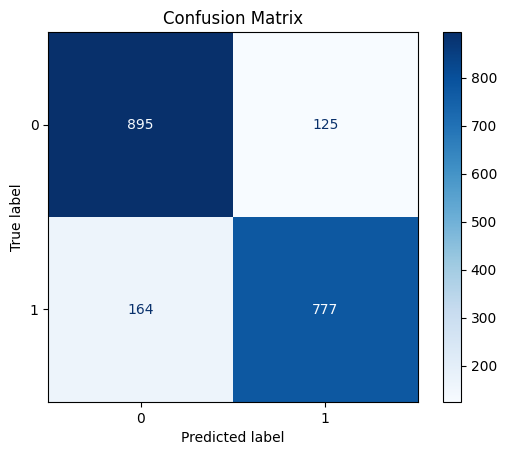

In [25]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### **Interpretation & Summary:**

#### **1. Confusion Matrix**
    - Shows how well the classification model performed in predicting population change catergories
    - Compares the actual Class Labels (y_labels) wth the Predicted Class Labels (y_pred)
    - Allows to see where the model was correct and where it made errors - helping assess model's reliability and balance between classes

**Summary:**
   - This visually represents how well the model performed in classifying the two classes (0 and 1)
   - It compares actual labels (true values) against predicted labels (model outputs)

```
    True Label ↓ / Predicted →     0       1
        0                         895     125
        1                         164     777
```

**Component Breakdown:**
• True Negatives (TN = 895):
  - Model correctly predicted 0 (no population growth) when the actual value was 0.
  → Indicates strong recognition of stable or decreasing population cases.

• False Positives (FP = 125):
  - Model predicted 1 (growth) when the actual value was 0.
  → These are overestimations, where the model wrongly assumed population growth.

• False Negatives (FN = 164):
  - Model predicted 0 (no growth) when the actual value was 1.
  → These are missed cases where growth actually occurred but wasn’t detected.

• True Positives (TP = 777):
  - Model correctly predicted 1 (population growth) when the actual value was 1.
  → Shows accurate identification of areas with real growth trends.

**Interpretation:**
    
    • The model correctly classified 895 negatives (class 0) and 777 positives (class 1), most predictions lie on the main diagonal (895 and 777), meaning the model correctly classified the majority of test cases.

    • Misclassifications include 125 false positives and 164 false negatives, which are relatively low compared to the total number of sample which indicates few incorrect classifications

    • The high values along the diagonal indicate strong overall accurancy

    • The classifier demonstrates balanced performance - evenly across both categories, effectively identifying both classes without major bias toward predicting only “growth” or “no growth.”

    • Overall, the confusion matrix confirms that the model performs reliably and consistently in predicting outcomes and reveals that the model has high predictive accuracy and strong consistency in results.


In [26]:
# Predicted Probabilities (for ROC Curve)
# RandomForestClassifier supports predict_proba()

y_prob = random_forest_model.predict_proba(X_test)

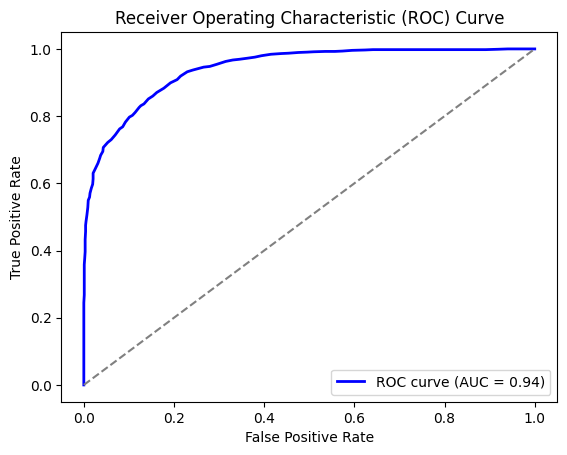

Area Under Curve (AUC): 0.94


In [27]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Print out the AUC Value
print(f"Area Under Curve (AUC): {roc_auc:.2f}")

#### **Interpretation & Summary:**

#### **2. ROC Curve and AUC**
    - The ROC Curve is a graphical tool that evaluates how well a classification model distinguishes between two class in this case, Population Growth (1) and No Growth (0)

    - The Area Under the Curve (AUC) quantifies this performance into a single value between 0 and 1:

    AUC = 1.0 → perfect classifier

    AUC = 0.5 → random guessing

    The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various classification thresholds, showing how sensitivity and specificity trade off as the threshold changes.

**Summary:**
   - The Receiver Operating Characteristic (ROC) Curve shows the model's ability to distinguish between two classes at different probability thresholds
   - It plots the True Positive Rate (Sensitivity) againts the False Positive Rate (1 - Specificity)


**Interpretation:**
    
    • The ROC curve rises steeply toward the top-left corner, showing strong model performance with high sensitivity and low false positive rate. It indicates that the model effectively differentiates between municipalities experiencing population growth and those that do not.

    Metric, Description and Value: 
    1. AUC (Area Under Curve) = 0.94
       - Measures how well the model separates classes
       - Summarizes the model’s ability to rank predictions correctly.
       - An AUC of 0.94 means that there’s a 94% probability the model will correctly assign a higher score to a random “growth” case than to a random “no growth” case.
    
    2. FPR (Flase Positive Rate) = Low
       - Fraction of non-growth cases incorrectly classified as growth
       - Indicates how often the model incorrectly flags a non-growth case as growth.
       - A lower FPR means the model avoids false alarms and is more precise.

       Formula: FPR = FP / (FP + TN)

    3. TPR (True Positive Rate) = High
       - Fraction of true growth cases correctly identified
       - Also called Sensitivity or Recall, this measures how effectively the model detects true growth cases.
       - A higher TPR indicates the model rarely misses growth trends.
       
       Formula: TPR = TP / (TP + FN)

    • The Area Under the Curve (AUC) is 0.94, indicating excellent discriminatory ability

    • An AUC close to 1.0 suggests that the model can successfully differentiate between positive and negative instances in nearly all cases.

    • The ROC curve confirms that the model performs significantly better than random guessing (gray diagonal line).


### **Conclusion**
 
• Both the Confusion Matrix and ROC Curve highlight that the model provides accurate, balanced, and highly reliable predictions, with minimal misclassifications and excellent class separation.

• The confusion matrix results show that the model correctly identified most cases of population growth and non-growth, achieving an overall accuracy of about 85%.

• The ROC curve, with an AUC score of 0.94, confirms the model’s strong ability to distinguish between the two classes

Together, these findings indicate that the classification model performs effectively and consistently, demonstrating both precision and robustness in forecasting population growth trends across Philippine municipalities.

#### **11. Performance Metrics**

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Accuracy: 0.8526262111167772

Confusion Matrix:
 [[895 125]
 [164 777]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86      1020
           1       0.86      0.83      0.84       941

    accuracy                           0.85      1961
   macro avg       0.85      0.85      0.85      1961
weighted avg       0.85      0.85      0.85      1961



##### Model Performance Summary

1. **Accuracy**:
- The model has an **accuracy** of **85.26%**, meaning it correctly predicted the class for 85.26% of the data.

2. **Confusion Matrix**:
- **True Negatives (TN)**: 895 (Correctly predicted as class 0)
- **False Positives (FP)**: 125 (Incorrectly predicted as class 1 when they are actually class 0)
- **False Negatives (FN)**: 164 (Incorrectly predicted as class 0 when they are actually class 1)
- **True Positives (TP)**: 777 (Correctly predicted as class 1)

3. **Classification Report**:
- **Class 0** (e.g., non-spam):
  - **Precision**: 0.85 (Of the predicted class 0 instances, 85% were actually class 0)
  - **Recall**: 0.88 (Of the actual class 0 instances, 88% were correctly identified)
  - **F1-score**: 0.86 (The harmonic mean of precision and recall for class 0)
  
- **Class 1** (e.g., spam):
  - **Precision**: 0.86 (Of the predicted class 1 instances, 86% were actually class 1)
  - **Recall**: 0.83 (Of the actual class 1 instances, 83% were correctly identified)
  - **F1-score**: 0.84 (The harmonic mean of precision and recall for class 1)

4. **Averages**:
- **Macro Average**: 
  - Precision: 0.85
  - Recall: 0.85
  - This is the average across both classes, not considering class imbalance.
  
- **Weighted Average**: 
  - Precision: 0.85
  - Recall: 0.85
  - F1-score: 0.85
  - This takes into account the support (number of instances) for each class.

**Interpretation:**
- The model is performing well with an accuracy rate of 85%.
- Class 0 is slightly better identified than class 1, as indicated by its higher recall.
- The **F1-score** is relatively high for both classes, meaning the model balances precision and recall effectively.
- The **weighted average** shows that class 0, being more prevalent, has a higher impact on overall performance.



#### **12. Conclusion**

The performance evaluation of the classification model, based on the accuracy score, confusion matrix, and classification report, provides a clear view of how effectively the model distinguishes between the different target classes. The accuracy score offers a general measure of correctness, but the precision, recall, and F1-scores in the classification report provide deeper insight into how well the model performs for each class individually. The confusion matrix further highlights specific patterns of misclassification, which is useful in identifying whether certain classes are more difficult to predict and why that may be the case.

If the model shows imbalanced performance across classes, this may indicate issues such as class imbalance in the dataset, insufficient feature representation, or the need for a more complex model. Potential improvements include hyperparameter tuning, feature engineering, collecting additional data, or experimenting with more advanced algorithms. Techniques like oversampling or applying class weights could also be beneficial if the dataset is imbalanced.

Overall, the results help reveal underlying trends in the data and demonstrate how well the model generalizes to unseen inputs. The analysis underscores both the strengths of the model and meaningful opportunities for refinement to further enhance predictive reliability in real-world scenarios.